In [ ]:
import keras
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import seaborn as sns

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

## **Exploring Data**

In [170]:
df = pd.read_csv('Weather_in_london.csv')

In [171]:
df.shape

(10000, 11)

In [172]:
df.head()

,index,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,0,19790101,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1,1,19790102,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
2,2,19790103,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
3,3,19790104,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
4,4,19790105,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0


In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   index             10000 non-null  int64  
 1   date              10000 non-null  int64  
 2   cloud_cover       9986 non-null   float64
 3   sunshine          10000 non-null  float64
 4   global_radiation  9987 non-null   float64
 5   max_temp          10000 non-null  float64
 6   mean_temp         9993 non-null   float64
 7   min_temp          10000 non-null  float64
 8   precipitation     10000 non-null  float64
 9   pressure          9999 non-null   float64
 10  snow_depth        9986 non-null   float64
dtypes: float64(9), int64(2)
memory usage: 859.5 KB


In [174]:
# Changing the date column from integer to datetime
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')

In [175]:
df.head()

,index,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,0,1979-01-01,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1,1,1979-01-02,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
2,2,1979-01-03,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
3,3,1979-01-04,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
4,4,1979-01-05,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0


In [176]:
df.drop(columns=['index'], inplace=True)

In [177]:
df.shape

(10000, 10)

In [178]:
df.describe()

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
count,10000,9986.000000,10000.000000,9987.000000,10000.000000,9993.000000,10000.000000,10000.000000,9999.000000,9986.000000
mean,1992-09-08 12:00:00,5.493491,4.415580,119.361170,15.048550,11.164355,7.278230,1.633010,101552.645265,0.040557
min,1979-01-01 00:00:00,0.000000,0.000000,12.000000,-6.200000,-7.600000,-11.800000,0.000000,95960.000000,0.000000
25%,1985-11-04 18:00:00,4.000000,0.400000,42.000000,10.200000,6.700000,3.200000,0.000000,100920.000000,0.000000
50%,1992-09-08 12:00:00,6.000000,3.600000,95.000000,14.600000,11.100000,7.500000,0.000000,101640.000000,0.000000
75%,1999-07-14 06:00:00,7.000000,7.300000,187.000000,19.900000,15.600000,11.500000,1.500000,102260.000000,0.000000
max,2006-05-18 00:00:00,8.000000,15.700000,352.000000,37.900000,29.000000,21.200000,61.800000,104430.000000,22.000000
std,NaN,1.869773,4.068382,89.437142,6.531261,5.728316,5.345578,3.728305,1047.630908,0.601165


In [179]:
df.isnull().sum()

date                 0
cloud_cover         14
sunshine             0
global_radiation    13
max_temp             0
mean_temp            7
min_temp             0
precipitation        0
pressure             1
snow_depth          14
dtype: int64

This dataset should be cleaned before using it because it will create problems later on.

In [180]:
df.dropna(inplace=True)

In [181]:
df.shape

(9951, 10)

In [182]:
df.duplicated().sum()

0

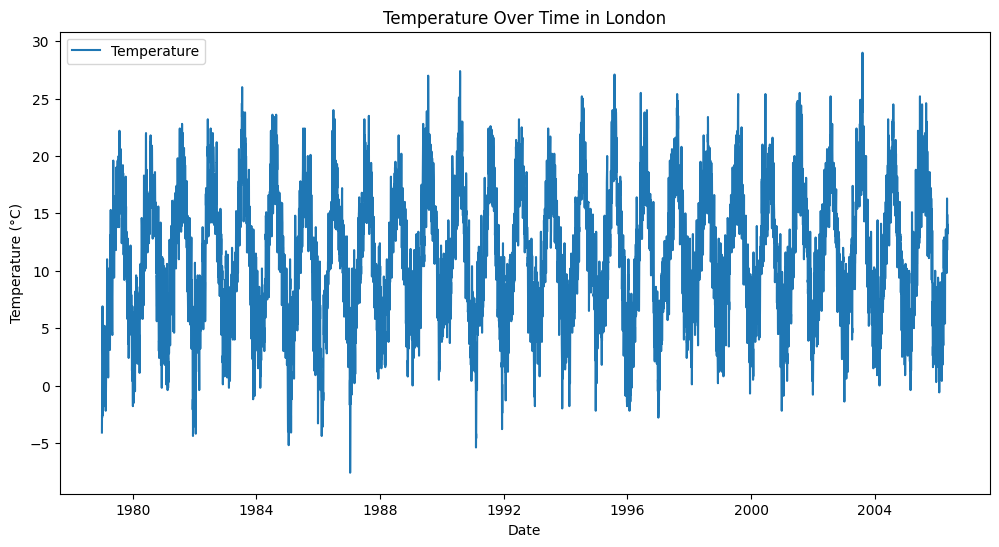

In [183]:
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['mean_temp'], label='Temperature')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Over Time in London')
plt.legend()
plt.show()

In [184]:
for col in df.columns:
    if df[col].dtype != 'datetime64[ns]':
        print(f'Column: {col}')
        print(df[col].value_counts())
        print('---')
        print(df[col].nunique())
        print('\n')

Column: cloud_cover
cloud_cover
7.0    2286
6.0    2189
5.0    1634
8.0    1211
4.0    1135
3.0     668
2.0     443
1.0     281
0.0     104
Name: count, dtype: int64
---
9


Column: sunshine
sunshine
0.0     1686
0.1      387
0.2      185
0.3      161
0.4      113
        ... 
15.5       5
15.3       5
15.4       4
15.7       3
15.6       2
Name: count, Length: 158, dtype: int64
---
158


Column: global_radiation
global_radiation
12.0     237
13.0     180
16.0     119
15.0     113
17.0     103
        ... 
351.0      2
319.0      2
344.0      2
352.0      1
328.0      1
Name: count, Length: 340, dtype: int64
---
340


Column: max_temp
max_temp
 12.6    83
 11.1    78
 11.5    76
 13.9    74
 12.2    74
         ..
 36.5     1
 34.4     1
-2.1      1
-2.5      1
 33.7     1
Name: count, Length: 362, dtype: int64
---
362


Column: mean_temp
mean_temp
 10.8    99
 15.4    97
 8.0     95
 6.8     95
 11.2    94
         ..
-5.4      1
-4.6      1
-3.4      1
-3.8      1
-3.0      1
Name: c

In [185]:
df.head()

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,1979-01-01,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1,1979-01-02,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
2,1979-01-03,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
3,1979-01-04,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
4,1979-01-05,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0


# CNN Time Series

## **Data Manipulation**

In [186]:
df_CNN = df[['date', 'cloud_cover', 'mean_temp']]

In [187]:
df_CNN.head()

,date,cloud_cover,mean_temp
0,1979-01-01,2.0,-4.1
1,1979-01-02,6.0,-2.6
2,1979-01-03,5.0,-2.8
3,1979-01-04,8.0,-2.6
4,1979-01-05,6.0,-0.8


In [188]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

num_cols = ['cloud_cover', 'mean_temp']
df_CNN[num_cols] = scaler.fit_transform(df_CNN[num_cols])
df_CNN.head()

C:\Users\Chourouk\AppData\Local\Temp\ipykernel_27900\3691867022.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_CNN[num_cols] = scaler.fit_transform(df_CNN[num_cols])


,date,cloud_cover,mean_temp
0,1979-01-01,0.250,0.095628
1,1979-01-02,0.750,0.136612
2,1979-01-03,0.625,0.131148
3,1979-01-04,1.000,0.136612
4,1979-01-05,0.750,0.185792


In [189]:
df_CNN["sequence"] = df_CNN.index + 1
df_CNN = df_CNN.drop("date", axis=1)
df_CNN.head()

C:\Users\Chourouk\AppData\Local\Temp\ipykernel_27900\2571812979.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_CNN["sequence"] = df_CNN.index + 1


,cloud_cover,mean_temp,sequence
0,0.250,0.095628,1
1,0.750,0.136612,2
2,0.625,0.131148,3
3,1.000,0.136612,4
4,0.750,0.185792,5


In [190]:
df_CNN.tail()

,cloud_cover,mean_temp,sequence
9986,0.125,0.653005,9987
9987,0.625,0.530055,9988
9988,0.875,0.614754,9989
9989,0.875,0.568306,9990
9990,0.750,0.590164,9991


In [191]:
df_CNN.dropna(inplace=True)

In [192]:
df_CNN.drop_duplicates(inplace=True)

In [193]:
df_CNN.shape

(9951, 3)

In [194]:
from numpy.lib.stride_tricks import sliding_window_view

timestep = 50  
data_values = df_CNN[['cloud_cover', 'mean_temp']].values

cloud_cover = df_CNN['cloud_cover'].values
mean_temp = df_CNN['mean_temp'].values

mean_temp_windows = sliding_window_view(mean_temp, window_shape=timestep)
cloud_cover_windows = sliding_window_view(cloud_cover, window_shape=timestep)

X = np.vstack((cloud_cover_windows, mean_temp_windows))

y = np.array([0]*len(cloud_cover_windows) + [1]*len(mean_temp_windows))

print("X:", X.shape)
print("y:", y.shape)

X: (19804, 50)
y: (19804,)


In [195]:
from sklearn.utils import shuffle

# shuffle the data
X, y = shuffle(X, y, random_state=42)

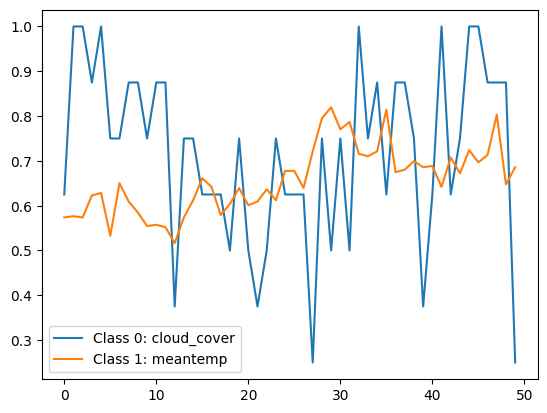

In [196]:
test_signal_index = 2

c_x_train = X[y == 0]
plt.plot(c_x_train[test_signal_index], label="Class 0: cloud_cover")

c_x_train = X[y == 1]
plt.plot(c_x_train[test_signal_index], label="Class 1: meantemp")
plt.legend()

## **Train/test -split**

In [197]:
train_size = 0.7
splitter = int(len(X) * train_size)

# split to train/test
x_train = X[0:splitter]
x_test = X[splitter:]
y_train = y[0:splitter]
y_test = y[splitter:]

In [198]:
print(len(x_train))
print(len(x_test))
print(len(y_train))
print(len(y_test))

13862
5942
13862
5942


In [199]:
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))

In [200]:
x_train

array([[[0.66666667],
        [0.59562842],
        [0.61748634],
        ...,
        [0.55191257],
        [0.50273224],
        [0.52459016]],

       [[0.75      ],
        [0.375     ],
        [0.5       ],
        ...,
        [0.625     ],
        [0.625     ],
        [0.875     ]],

       [[0.63387978],
        [0.7295082 ],
        [0.67213115],
        ...,
        [0.72131148],
        [0.80874317],
        [0.81420765]],

       ...,

       [[0.62295082],
        [0.66666667],
        [0.63934426],
        ...,
        [0.3989071 ],
        [0.45901639],
        [0.4863388 ]],

       [[0.875     ],
        [0.875     ],
        [0.625     ],
        ...,
        [1.        ],
        [1.        ],
        [1.        ]],

       [[0.53551913],
        [0.67759563],
        [0.58469945],
        ...,
        [0.70765027],
        [0.72131148],
        [0.69672131]]])

## **Define a CNN- time series classification network for our data**

In [201]:
class_names = np.array(['cloud_cover', 'mean_temp'])  

num_classes = len(class_names)
classes = [0, 1]

def make_model(input_shape):
    model = keras.Sequential(
        [
            keras.layers.Input(input_shape),

            keras.layers.Conv1D(filters=64, kernel_size=3, padding="same"),
            keras.layers.BatchNormalization(),
            keras.layers.ReLU(),

            keras.layers.GlobalAveragePooling1D(),
            keras.layers.Flatten(),

            keras.layers.Dense(64, activation="relu"),

            keras.layers.Dense(num_classes, activation="softmax")
        ]
    )

    return model


model = make_model(input_shape=x_train.shape[1:])

During the initial training the model showed some problems when it comes to the val loss. I had to adjust the epochs to get the model to train properly. And as part of the optimisation, I added an early stopping callback to prevent overfitting. Also i had to reduce the learning rate so my model would converge.


In [202]:
epochs = 200
batch_size = 32
opt = keras.optimizers.Adam(learning_rate=1e-4)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_model2.keras", save_best_only=True, monitor="val_loss"
    ),    
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

]
model.compile(
    optimizer=opt,
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"],
)
history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    callbacks=callbacks,
    validation_split=0.2,
    verbose=1,
)


Epoch 1/200
347/347 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.4118 - sparse_categorical_accuracy: 0.7674 - val_loss: 0.5839 - val_sparse_categorical_accuracy: 0.7908
Epoch 2/200
347/347 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2279 - sparse_categorical_accuracy: 0.8977 - val_loss: 0.2185 - val_sparse_categorical_accuracy: 0.9946
Epoch 3/200
347/347 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1275 - sparse_categorical_accuracy: 0.9961 - val_loss: 0.0995 - val_sparse_categorical_accuracy: 0.9989
Epoch 4/200
347/347 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0703 - sparse_categorical_accuracy: 0.9987 - val_loss: 0.0572 - val_sparse_categorical_accuracy: 1.0000
Epoch 5/200
347/347 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0398 - sparse_categorical_accuracy: 0.9993 - val_loss: 0.0300 - val_sparse_categorical_accuracy: 1.0000
Epoch 6/200
347/347 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0236 - sparse_categorical_accuracy: 0.9994 - val_loss: 0.0192 - val_sparse_categorical_accuracy: 1.000

## **Metrics and plots**

<Axes: >

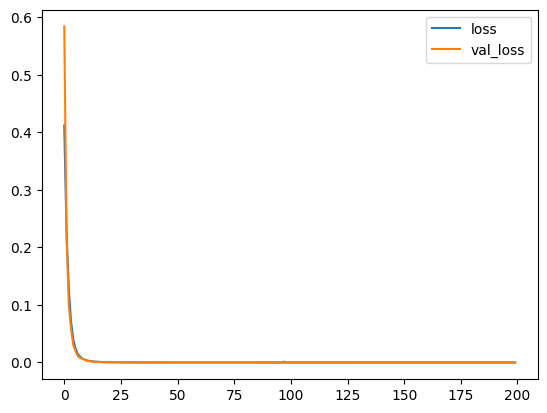

In [203]:
loss_df = pd.DataFrame(model.history.history)
loss_df[['loss', 'val_loss']].plot()

<Axes: >

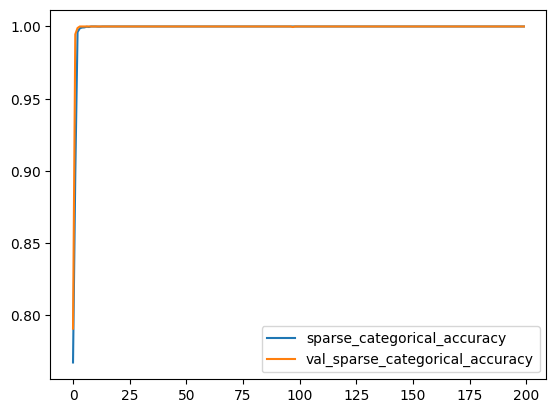

In [204]:
loss_df[['sparse_categorical_accuracy', 'val_sparse_categorical_accuracy']].plot()

In [205]:
model = keras.models.load_model("best_model2.keras")

In [206]:
# compare the final model loss/accuracy/evaluation values
# the values should again match mostly
print("Test data evaluation:")
print(model.evaluate(x_test, y_test, verbose=0))
print("\nTrain data evaluation:")
print(model.evaluate(x_train, y_train, verbose=0))

Test data evaluation:
[7.222372699899893e-10, 1.0]

Train data evaluation:
[3.9558697983999025e-10, 1.0]


In [207]:
# get predictions and convert with argmax() to get categories 
# instead of raw probabilities
test_predictions = model.predict(x_test)
test_predictions = np.argmax(test_predictions, axis=1)

186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [245]:
auc_macro = roc_auc_score(y_test, test_predictions, multi_class='ovr', average='macro')
print(f"ROC-AUC (macro, OVR): {auc_macro:.4f}")

ROC-AUC (macro, OVR): 1.0000


<Axes: >

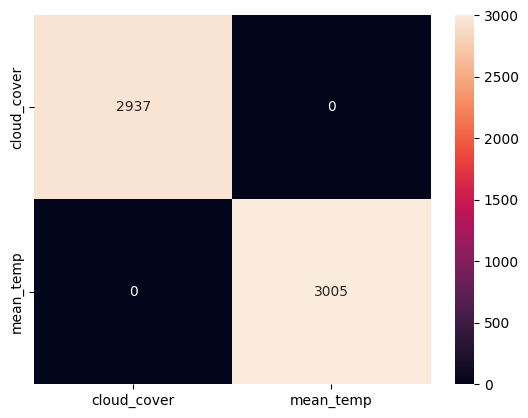

In [ ]:
sns.heatmap(confusion_matrix(y_test, test_predictions), annot=True, fmt='g', 
            xticklabels=class_names, yticklabels=class_names)

In [209]:
# print the classification report based on true values and predictions
print(classification_report(y_test, test_predictions, target_names=class_names))

# get overall accuracy of the model and print it
acc = accuracy_score(y_test, test_predictions)
print("\nModel overall accuracy: {:.2f}%".format(acc * 100))


              precision    recall  f1-score   support

 cloud_cover       1.00      1.00      1.00      2937
   mean_temp       1.00      1.00      1.00      3005

    accuracy                           1.00      5942
   macro avg       1.00      1.00      1.00      5942
weighted avg       1.00      1.00      1.00      5942


Model overall accuracy: 100.00%


My Reflection on the metrics : 

The model got perfect results which is great on paper, it’s honestly too good to be true for a real-world problem. In real situations, time series data are noisy, unpredictable and rarely allow a model to classify everything perfectly.

The ROC-AUC = 1 also supports perfect separability i guess due to strong signal differences between variables.

Two potential interepretation : 
- The dataset was quite simple 
- The patterns between the two classes were very easy for the CNN to separate.

So even though the metrics look perfect, i wouldn’t expect this model to perform the same way with new or messier data. 

# Test the model with some imaginary/synthetic signal examples from your favorite Generative AI

ChatGPT generated this data based on the stats of my variables. Yes it worked but i guess if it is a more random data this model would be confused. Real data usually isn’t this clean so in real life the accuracy would definitely drop.

## **CLOUD COVER**

0
cloud_cover


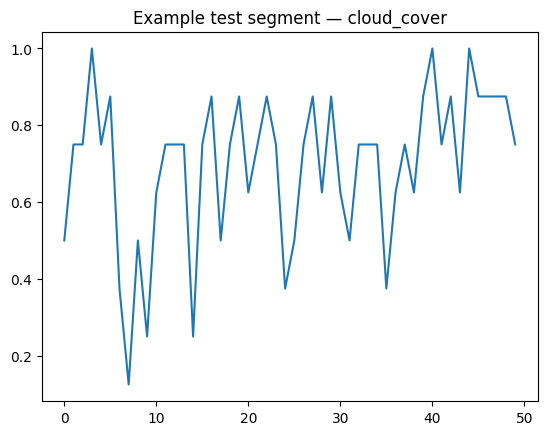

In [ ]:
signal_index = int(np.where(y_test == 0)[0][0])  
print(y_test[signal_index])
print(class_names[y_test[signal_index]])

plt.figure()
plt.plot(x_test[signal_index])
plt.title("Example test segment — cloud_cover")
plt.show()

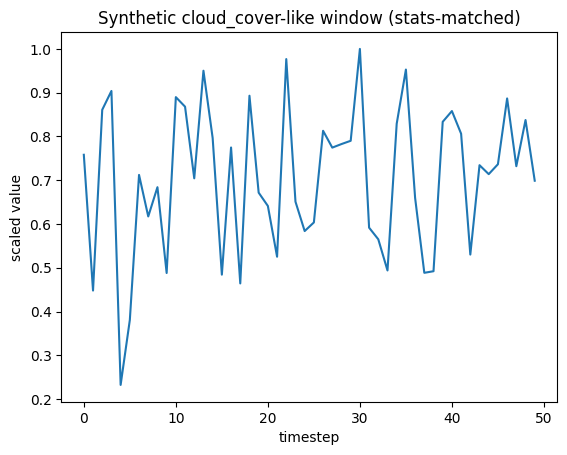

In [ ]:
# =========================
# IMAGINARY MEAN Cloud Coverage SIGNAL with chatgpt
# =========================

cloud_idxs = np.where(y_test == 0)[0]
cloud_windows = x_test[cloud_idxs, :, 0]   

cloud_mean_per_t = cloud_windows.mean(axis=0)       
cloud_std_overall = cloud_windows.std()            
cloud_min, cloud_max = cloud_windows.min(), cloud_windows.max()


t = x_test.shape[1]
rng = np.random.default_rng(42)

y = cloud_mean_per_t + rng.normal(0, cloud_std_overall, size=t)

y = np.clip(y, cloud_min, cloud_max)

plt.plot(y)
plt.title("Synthetic cloud_cover-like window (stats-matched)")
plt.xlabel("timestep"); plt.ylabel("scaled value")
plt.show()

In [ ]:
test_signal = np.expand_dims(y, axis=1)    
test_batch  = np.array([test_signal])      
probs = model.predict(test_batch)[0]
print("Pred probs:", probs)
print(class_names[np.argmax(probs)])

## **MEAN TEMPERATURE**

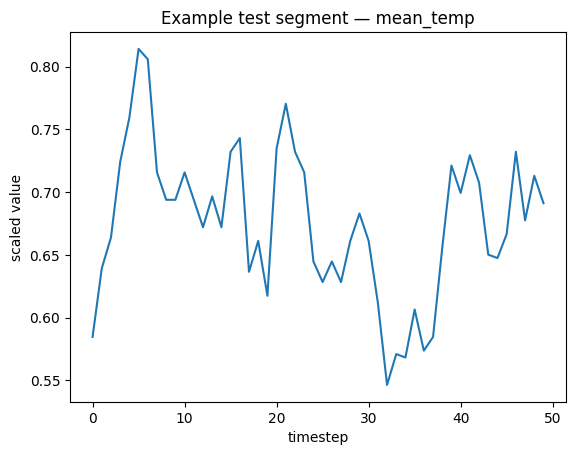

In [243]:
mean_temp_index = np.where(y_test == 1)[0][0]  


plt.plot(x_test[mean_temp_index])
plt.title("Example test segment — mean_temp")
plt.xlabel("timestep")
plt.ylabel("scaled value")
plt.show()

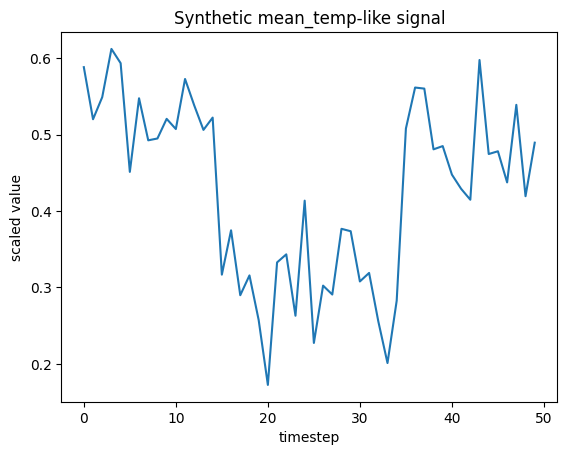

In [237]:
# =========================
# IMAGINARY MEAN TEMPERATURE SIGNAL with chatgpt
# =========================
t = x_test.shape[1]
x = np.arange(t)

np.random.seed(0)
y = 0.5 + np.random.normal(0, 0.05, size=t) 
mid = t // 2
y[mid - t//5 : mid + t//5] -= 0.2  
y = np.clip(y, 0, 1)

plt.plot(x, y)
plt.xlabel('timestep')
plt.ylabel('scaled value')
plt.title('Synthetic mean_temp-like signal')
plt.show()

In [240]:
# TRY OUR IMAGINARY MEAN TEMPERATURE SIGNAL WITH THE MODEL
test_signal = np.expand_dims(y, axis=1)
test_batch = np.array([test_signal])

test_predict = model.predict(test_batch)
print(test_predict)
print(class_names[np.argmax(test_predict)])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
[[4.5930335e-07 9.9999952e-01]]
mean_temp
